In [50]:
import geopandas as gpd
import fiona

In [51]:
# Set path to folder containing state watershed data
gdb_path = "data/NHD_H_Arizona_State_GDB/NHD_H_Arizona_State_GDB.gdb"
layers = fiona.listlayers(gdb_path)

# Set HUC number (eg. HUC12, HUC8, HUC6 etc.)
n_HUC = 6

# Then open specific layer
gdf_huc = gpd.read_file(gdb_path, layer = f"WBDHU{n_HUC}")
print(gdf_huc.shape)

(18, 15)


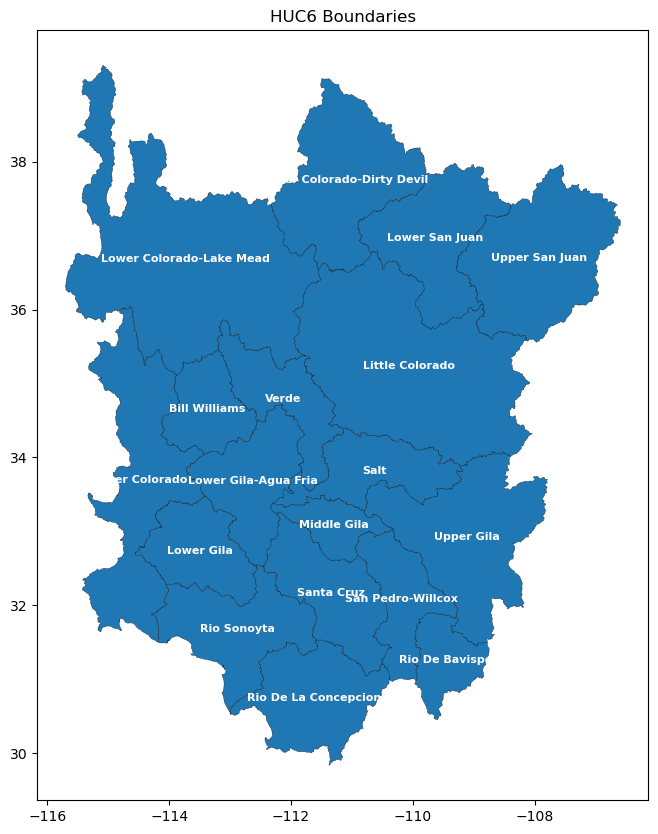

In [52]:
import matplotlib.pyplot as plt

# Create the plot and capture the axis (ax)
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the HUC boundaries
gdf_huc.plot(ax=ax, edgecolor='black', linewidth=0.2)

# --- ADD LABELS FOR EACH POLYGON ---
for idx, row in gdf_huc.iterrows():
    # Get the center point of the polygon
    centroid = row.geometry.centroid
    
    # Extract the name string
    name_label = str(row['name'])
    
    # Place text at the centroid coordinate
    ax.text(
        x=centroid.x, 
        y=centroid.y, 
        s=name_label, 
        fontsize=8, 
        ha='center',      # Horizontally center text on the point
        va='center',      # Vertically center text on the point
        color='white',  # Dark slate color for readability
        weight='bold',
        wrap=True         # Wraps long names to prevent overlap
    )

plt.title(f"HUC{n_HUC} Boundaries")
plt.show()

In [53]:
gdf_huc.head()

,tnmid,metasourceid,sourcedatadesc,sourceoriginator,sourcefeatureid,loaddate,referencegnis_ids,areaacres,areasqkm,states,huc6,name,shape_Length,shape_Area,geometry
0,{E0F3CFD8-C698-43A7-B155-E1545F94D259},None,None,None,None,2020-12-07 10:01:19+00:00,None,9287345.93,37584.59,"AZ,CO,NM",140801,Upper San Juan,12.336555,3.789947,"MULTIPOLYGON (((-107.56846 37.96204, -107.5681..."
1,{A938748F-0DB7-42B7-B44E-84AF773ED95F},{566E7651-2594-4C85-AE09-DB338B355F62},3D Elevation Product 1/3 Arc-second 1 x 1 degr...,U.S. Geological Survey,None,2021-06-30 16:16:00+00:00,None,6358139.56,25730.50,"AZ,MX",150802,Rio De La Concepcion,10.602049,2.423928,"MULTIPOLYGON (((-111.57608 31.53927, -111.5760..."
2,{0BB93966-9ED1-4D3A-BAFF-FE8430DA7CC1},{066D2059-B82D-4F33-9816-BD9B5523EB4B},3D Elevation Product 1/3 Arc-second 1 x 1 degr...,U.S. Geological Survey,None,2021-10-28 17:46:50+00:00,None,4381818.31,17732.61,AZ,150601,Salt,12.140475,1.726828,"MULTIPOLYGON (((-111.09976 34.40256, -111.0992..."
3,{B8494BDF-1D56-4E49-94D9-C4A945F415D9},{566E7651-2594-4C85-AE09-DB338B355F62},3D Elevation Product 1/3 Arc-second 1 x 1 degr...,U.S. Geological Survey,None,2021-06-30 16:16:03+00:00,None,5491299.27,22222.52,"AZ,MX",150503,Santa Cruz,9.843430,2.124665,"MULTIPOLYGON (((-112.1801 33.2583, -112.17916 ..."
4,{90255862-DAEA-4376-A490-4D1B2E3E6D1B},{0798C084-7771-47E5-BD5C-F5CAF80EBC7A},3D Elevation Product 1/3 Arc-second 1 x 1 degr...,U.S. Geological Survey,None,2021-06-16 09:17:22+00:00,None,4424395.19,17904.91,AZ,150702,Lower Gila,8.184375,1.722540,"MULTIPOLYGON (((-113.41001 33.47865, -113.4099..."


In [54]:
# Set path for US states shapefile and read in
us_path = "data/US_State_Boundaries/US_State_Boundaries.shp"

us_states = gpd.read_file(us_path)


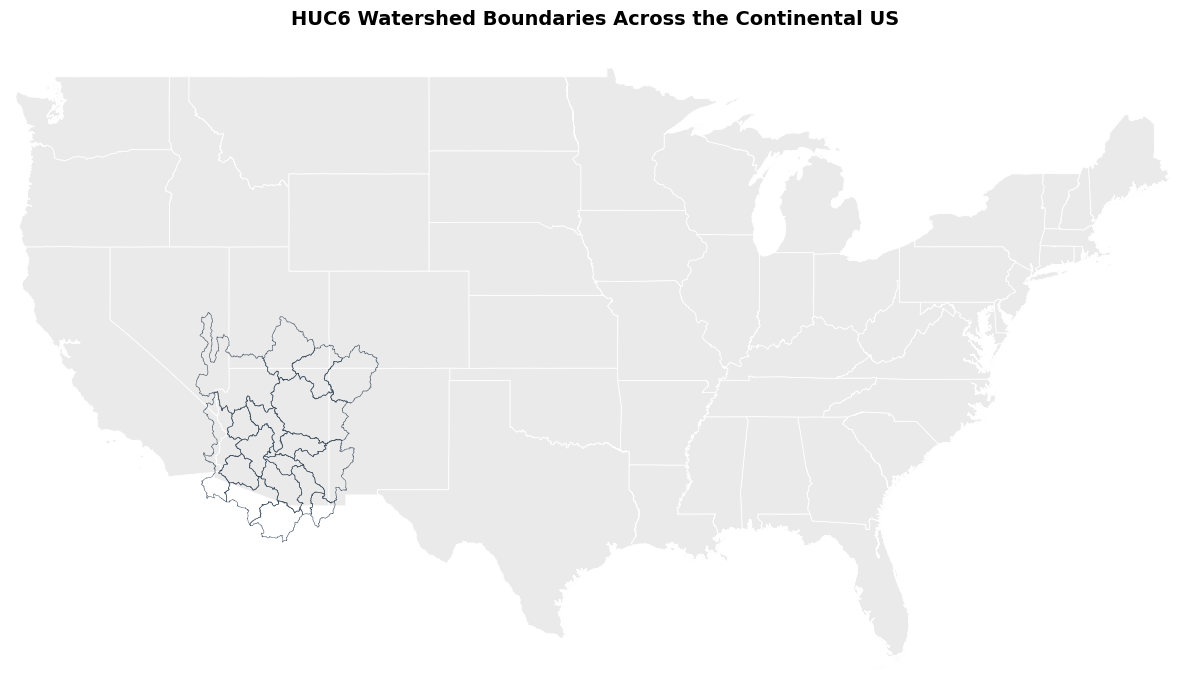

In [55]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Create the figure and axis explicitly
fig, ax = plt.subplots(figsize=(12, 8))

# Base layer: Continental US States
us_states.plot(
    ax=ax, 
    facecolor='#EAEAEA', 
    edgecolor='white', 
    linewidth=0.6, 
    label='US States'
)

# Top layer: HUC6 Watershed Boundaries
gdf_huc.plot(
    ax=ax, 
    facecolor='none', 
    edgecolor='#2C3E50', 
    linewidth=0.4, 
    alpha=0.8,
    label=f'HUC{n_HUC} Boundaries'
)

# --- SET BOUNDING BOX TO CENTER ON CONTINENTAL US ---
# Limits assume your data is in a Geographic Coordinate System (WGS84 / EPSG:4326)
ax.set_xlim([-125.0, -66.5])
ax.set_ylim([24.0, 50.0])

# 7. Clean up aesthetics
ax.axis('off')  # Removes lat/long grid ticks and the outer bounding box
plt.title(f"HUC{n_HUC} Watershed Boundaries Across the Continental US", fontsize=14, pad=20, weight='bold')

# Adjust layout and display map
plt.tight_layout()
plt.show()

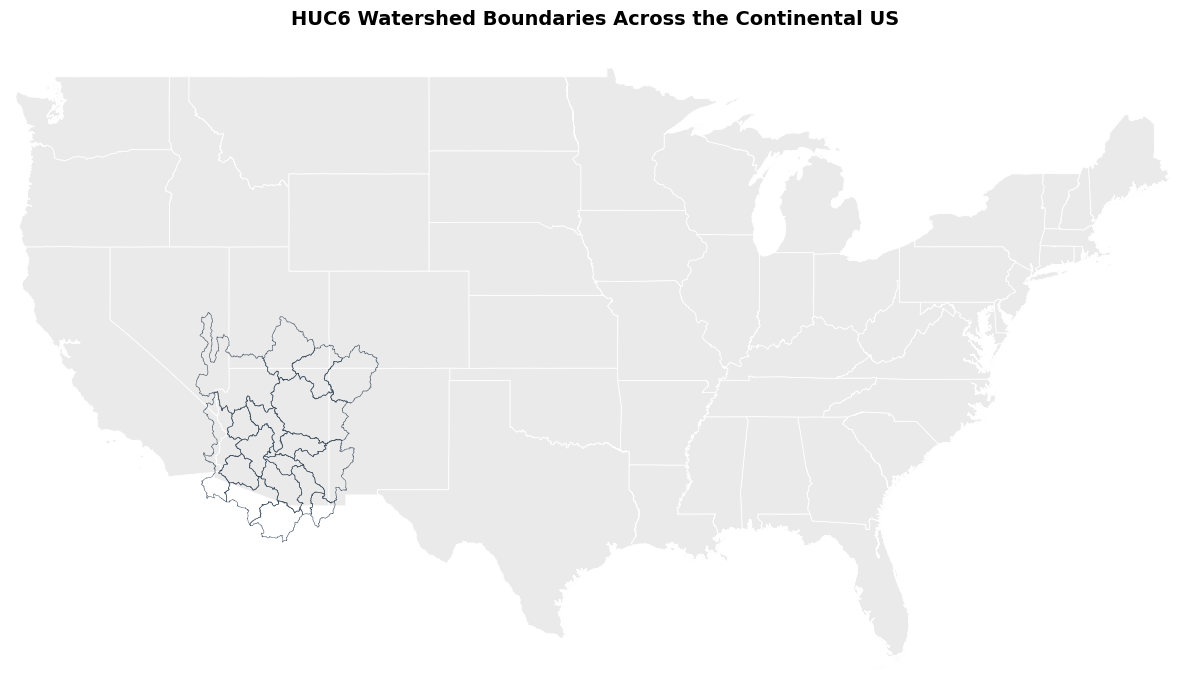

In [56]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Create the figure and axis explicitly
fig, ax = plt.subplots(figsize=(12, 8))

# Base layer: Continental US States
us_states.plot(
    ax=ax, 
    facecolor='#EAEAEA', 
    edgecolor='white', 
    linewidth=0.6, 
    label='US States'
)

# Top layer: HUC6 Watershed Boundaries
gdf_huc.plot(
    ax=ax, 
    facecolor='none', 
    edgecolor='#2C3E50', 
    linewidth=0.4, 
    alpha=0.8,
    label=f'HUC{n_HUC} Boundaries'
)

# --- SET BOUNDING BOX TO CENTER ON CONTINENTAL US ---
# Limits assume your data is in a Geographic Coordinate System (WGS84 / EPSG:4326)
ax.set_xlim([-125.0, -66.5])
ax.set_ylim([24.0, 50.0])

# 7. Clean up aesthetics
ax.axis('off')  # Removes lat/long grid ticks and the outer bounding box
plt.title(f"HUC{n_HUC} Watershed Boundaries Across the Continental US", fontsize=14, pad=20, weight='bold')

# Adjust layout and display map
plt.tight_layout()
plt.show()